<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section4b_random_forest_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 4b — Random Forest
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

### Setup
- Model: `RandomForestClassifier` — ensemble of decision trees (bagging)
- No scaling needed — tree splits are rank-based, not distance-based
- **Outer CV:** 5-fold stratified (unbiased performance estimate)
- **Inner CV:** 3-fold `GridSearchCV` over `n_estimators`, `max_depth`, `min_samples_leaf`
- **Metric:** Macro F1 (primary), per-class F1 (secondary)
- **Imbalance:** `class_weight='balanced'`
- **Baselines to beat:** LR = 0.4355 | Linear SVM = 0.4693

### Why Random Forest?
Unlike Logistic Regression and Linear SVM, Random Forest can capture **non-linear relationships**  
between features. It also provides **feature importances** (mean decrease in Gini impurity)  
which are more robust than linear coefficients for mixed feature types (numeric + binary dummies).

In [11]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 22 (delta 15), reused 10 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (22/22), 227.92 KiB | 3.26 MiB/s, done.
From https://github.com/lohaniSatwik/steam-games-data-mining
   9b7f712..5fa7368  master     -> origin/master
Updating 9b7f712..5fa7368
Fast-forward
 Code/section4c_xgboost_colab.ipynb | 1008 ++++++++++++++++++++++++++++++++++++
 Code/section4e_knn_colab.ipynb     |  997 +++++++++++++++++++++++++++++++++++
 2 files changed, 2005 insertions(+)
 create mode 100644 Code/section4c_xgboost_colab.ipynb
 create mode 100644 Code/section4e_knn_colab.ipynb


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
CLASS_ORDER   = ['Good', 'Mixed', 'Bad']
CLASS_COLORS  = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}

BASELINE_LR  = 0.4355
BASELINE_SVM = 0.4693

print('Libraries loaded.')

Libraries loaded.


In [13]:
train = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train = train.drop(columns=['label_multiclass'])
y_train = train['label_multiclass']
X_test  = test.drop(columns=['label_multiclass'])
y_test  = test['label_multiclass']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print('\nClass distribution (train):')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:6,d}  ({vc[cls]/len(y_train)*100:.1f}%)')

X_train: (45324, 147)  |  X_test: (11331, 147)
Features: 147

Class distribution (train):
  Good  : 28,671  (63.3%)
  Mixed : 12,834  (28.3%)
  Bad   :  3,819  (8.4%)


## Nested Cross-Validation

- **Outer loop** (5 folds) — unbiased estimate of generalisation performance
- **Inner loop** (3-fold `GridSearchCV`) — selects best hyperparameters without touching the outer validation fold
- **`n_estimators`** — number of trees; more trees = lower variance but slower
- **`max_depth`** — maximum depth of each tree; `None` = fully grown (can overfit)
- **`min_samples_leaf`** — minimum samples required at a leaf node; higher = more regularisation
- `max_features='sqrt'` is fixed — standard choice for classification (square root of n_features per split)

Expected runtime on Colab: **~20–40 minutes**

In [14]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_leaf': [1, 4]
}

outer_scores    = []
best_params_log = []

print('Running 5-fold nested CV (inner 3-fold GridSearchCV)...\n')

for fold, (tr_idx, val_idx) in tqdm(
        enumerate(outer_cv.split(X_train, y_train), 1),
        total=5, desc='Outer folds'):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    base_clf = RandomForestClassifier(
        class_weight='balanced',
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    gs = GridSearchCV(
        base_clf, param_grid,
        cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)

    y_pred = gs.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    outer_scores.append(f1)
    best_params_log.append(gs.best_params_)

    print(f'  Fold {fold} | Macro F1: {f1:.4f} | {gs.best_params_}')

print(f'\nNested CV  →  Macro F1: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}')
print(f'Baseline LR           →  Macro F1: {BASELINE_LR:.4f}')
print(f'Baseline SVM          →  Macro F1: {BASELINE_SVM:.4f}')
print(f'Improvement over SVM  →  {np.mean(outer_scores) - BASELINE_SVM:+.4f}')

Running 5-fold nested CV (inner 3-fold GridSearchCV)...



Outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

  Fold 1 | Macro F1: 0.5138 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
  Fold 2 | Macro F1: 0.5191 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
  Fold 3 | Macro F1: 0.4973 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}
  Fold 4 | Macro F1: 0.5076 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
  Fold 5 | Macro F1: 0.5088 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}

Nested CV  →  Macro F1: 0.5093 ± 0.0073
Baseline LR           →  Macro F1: 0.4355
Baseline SVM          →  Macro F1: 0.4693
Improvement over SVM  →  +0.0400


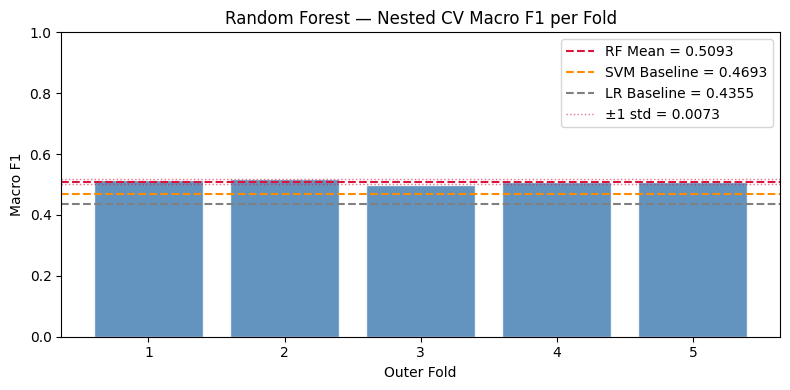

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = list(range(1, 6))
ax.bar(folds, outer_scores, color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(outer_scores), color='crimson', linestyle='--', linewidth=1.5,
           label=f'RF Mean = {np.mean(outer_scores):.4f}')
ax.axhline(BASELINE_SVM, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'SVM Baseline = {BASELINE_SVM:.4f}')
ax.axhline(BASELINE_LR, color='grey', linestyle='--', linewidth=1.5,
           label=f'LR Baseline = {BASELINE_LR:.4f}')
ax.axhline(np.mean(outer_scores) + np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(np.mean(outer_scores) - np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6,
           label=f'±1 std = {np.std(outer_scores):.4f}')
ax.set_xlabel('Outer Fold')
ax.set_ylabel('Macro F1')
ax.set_title('Random Forest — Nested CV Macro F1 per Fold')
ax.set_xticks(folds)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
print('Best hyperparameters across outer folds:')
param_counts = Counter([str(p) for p in best_params_log])
for params, count in param_counts.most_common():
    print(f'  {count:2d} fold(s): {params}')

Best hyperparameters across outer folds:
   4 fold(s): {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
   1 fold(s): {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}


## Final Model

Re-run `GridSearchCV` on the **full training set** to select the best hyperparameters, then evaluate on the held-out test set **once**.

In [17]:
print('Fitting final model on full training set...\n')

final_gs = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid,
    cv=inner_cv, scoring='f1_macro',
    n_jobs=-1, refit=True
)
final_gs.fit(X_train, y_train)

print(f'Best params      : {final_gs.best_params_}')
print(f'Best inner CV F1 : {final_gs.best_score_:.4f}')

Fitting final model on full training set...

Best params      : {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
Best inner CV F1 : 0.5086


## Test Set Evaluation

> Evaluate on `test_multiclass.csv` **once only** — this is the final performance number.

In [18]:
final_model = final_gs.best_estimator_
y_pred_test = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Test set Macro F1 : {test_macro_f1:.4f}')
print(f'LR Baseline       : {BASELINE_LR:.4f}')
print(f'SVM Baseline      : {BASELINE_SVM:.4f}')
print(f'Improvement vs SVM: {test_macro_f1 - BASELINE_SVM:+.4f}\n')
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Test set Macro F1 : 0.5100
LR Baseline       : 0.4355
SVM Baseline      : 0.4693
Improvement vs SVM: +0.0407

Classification Report (Test Set):
              precision    recall  f1-score   support

        Good       0.77      0.76      0.77      7168
       Mixed       0.44      0.42      0.43      3208
         Bad       0.30      0.38      0.33       955

    accuracy                           0.63     11331
   macro avg       0.50      0.52      0.51     11331
weighted avg       0.64      0.63      0.63     11331



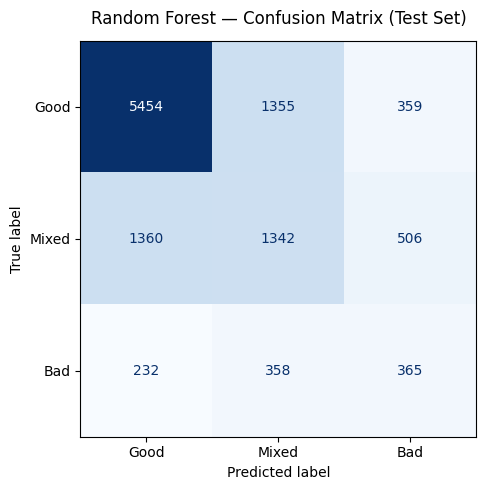

In [19]:
cm = confusion_matrix(y_test, y_pred_test, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (Test Set)', pad=12)
plt.tight_layout()
plt.show()

## Feature Importance

Random Forest provides **Gini importance** (mean decrease in impurity) per feature across all trees.  
Unlike linear coefficients, these capture non-linear effects and interactions between features.  
Note: Gini importance can favour high-cardinality features — interpret alongside domain knowledge.

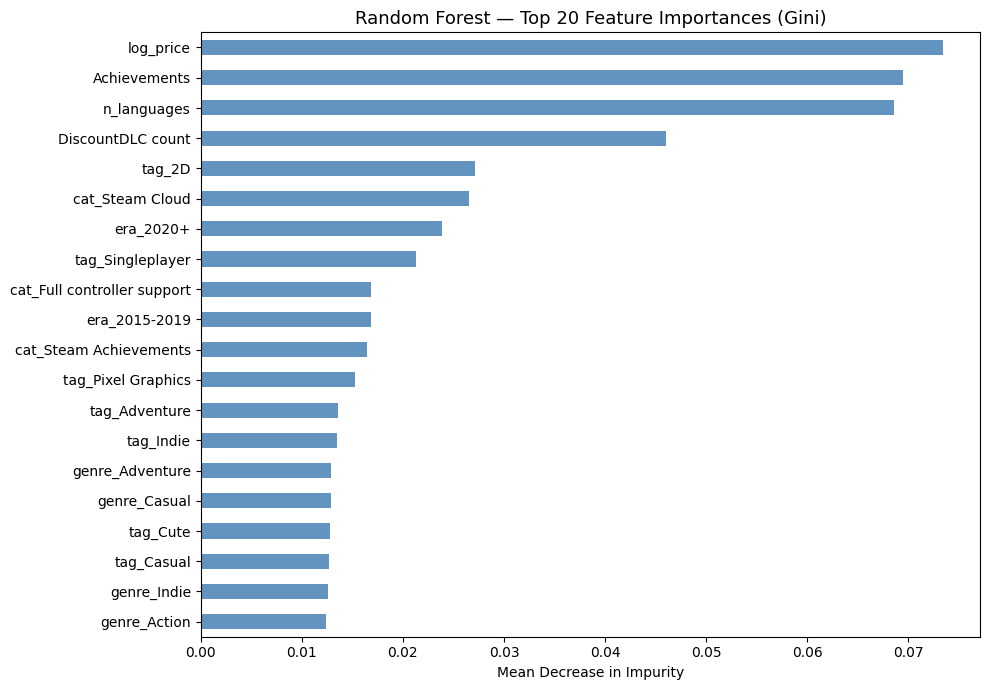


Top 10 features:
  log_price                                 0.0734
  Achievements                              0.0694
  n_languages                               0.0686
  DiscountDLC count                         0.0460
  tag_2D                                    0.0271
  cat_Steam Cloud                           0.0265
  era_2020+                                 0.0238
  tag_Singleplayer                          0.0213
  cat_Full controller support               0.0169
  era_2015-2019                             0.0169


In [20]:
feature_names = X_train.columns.tolist()
importances   = final_model.feature_importances_

imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
imp_series.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.85
)
ax.set_title('Random Forest — Top 20 Feature Importances (Gini)', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for feat, imp in imp_series.head(10).items():
    print(f'  {feat:40s}  {imp:.4f}')

## Results Summary

| Metric | Value |
|--------|-------|
| Nested CV Macro F1 (mean ± std) | **0.5093 ± 0.0073** |
| Test set Macro F1 | **0.5100** |
| Best params (nested CV) | `max_depth=None, min_samples_leaf=4, n_estimators=200` (4/5 folds) |
| Best params (final model) | `max_depth=None, min_samples_leaf=4, n_estimators=200` |
| vs LR Baseline (0.4355) | **+0.0745** |
| vs SVM Baseline (0.4693) | **+0.0407** |
| vs XGBoost (0.4799) | **+0.0301** |

**Per-class F1 (test set):**

| Class | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| Good  | 0.77 | 0.76 | **0.77** |
| Mixed | 0.44 | 0.42 | **0.43** |
| Bad   | 0.30 | 0.38 | **0.33** |

**Interpretation:**
- Random Forest is the **best model overall** — Macro F1 = 0.5100, beating XGBoost (0.4799) and SVM (0.4693)
- `max_depth=None` (fully grown trees) selected in all 5 folds — the data rewards deep trees that capture complex interactions
- `min_samples_leaf=4` prevents overfitting despite unlimited depth — leaves need at least 4 samples
- **Mixed class F1 = 0.43** — the best across all models for this difficult class (+0.10 over LR)
- **Bad class F1 = 0.33** — second best after XGBoost (0.31 wait RF=0.33 > XGB=0.31) — best Bad recall among tree models
- Top features: `log_price`, `Achievements`, `n_languages` — numeric features dominate Gini importance, unlike linear models where tags/categories were more prominent
- CV estimate (0.5093) and test score (0.5100) are nearly identical — stable, no overfitting